In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
df = pd.read_csv("../Data/arxiv_csLG_filtered.csv")
print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Dataset loaded successfully!
   Shape: 7015 rows × 5 columns

First 5 rows:
          id                                              title  \
0  0704.1274   Parametric Learning and Monte Carlo Optimization   
1  0704.2668  Supervised Feature Selection via Dependence Es...   
2  0705.1585  HMM Speaker Identification Using Linear and No...   
3  0706.3679  Scale-sensitive Psi-dimensions: the Capacity M...   
4  0707.3390  Consistency of the group Lasso and multiple ke...   

                                            abstract categories  year  
0    This paper uncovers and explores the close r...  ['cs.LG']  2007  
1    We introduce a framework for filtering featu...  ['cs.LG']  2007  
2    Speaker identification is a powerful, non-in...  ['cs.LG']  2007  
3    Bounds on the risk play a crucial role in st...  ['cs.LG']  2007  
4    We consider the least-square regression prob...  ['cs.LG']  2007  


In [3]:
print(f"\nColumns      : {list(df.columns)}")
print(f"Year range   : {df['year'].min()} – {df['year'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nYear distribution:\n{df['year'].value_counts().sort_index()}")


Columns      : ['id', 'title', 'abstract', 'categories', 'year']
Year range   : 1999 – 2021
Missing values:
id            0
title         0
abstract      0
categories    0
year          0
dtype: int64

Year distribution:
year
1999       2
2000       6
2001       2
2002       2
2003       3
2004       2
2005      15
2006      19
2007      19
2008      32
2009      48
2010      94
2011      87
2012     111
2013     198
2014     234
2015     398
2016     461
2017     629
2018     194
2019     114
2020     806
2021    3539
Name: count, dtype: int64


In [4]:
original_len = len(df)


df = df.drop_duplicates(subset='abstract')
print(f"   Removed duplicates : {original_len - len(df)} rows")


df = df.dropna(subset=['abstract', 'year', 'id'])


df['abstract'] = df['abstract'].str.replace(r'\s+', ' ', regex=True).str.strip()
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df["cleaned_abstract"] = df["abstract"].apply(
    lambda x: " ".join(
        word for word in word_tokenize(
            re.sub(r'[^\w\s]', '', str(x).lower().replace('-',' '))
        )
        if word not in stop_words
    )
)



df['word_count']    = df['abstract'].str.split().str.len()
df['char_count']    = df['abstract'].str.len()
df['year']          = df['year'].astype(int)

print(f"   ✅ Cleaning done. Final shape: {df.shape}")

   Removed duplicates : 1 rows


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\oz25100\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\oz25100\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


   ✅ Cleaning done. Final shape: (7014, 8)


In [5]:
def assign_period(year):
    if year < 2010:
        return 'early (1999–2009)'
    elif year < 2015:
        return 'mid (2010–2014)'
    elif year < 2018:
        return 'growth (2015–2017)'
    else:
        return 'recent (2018–2021)'

df['period'] = df['year'].apply(assign_period)

print(f"\nPeriod distribution:")
print(df['period'].value_counts().sort_index())
print(f"\nPeriod + year cross-check:")
print(df.groupby('period')['year'].agg(['min', 'max', 'count']))


Period distribution:
period
early (1999–2009)      150
growth (2015–2017)    1488
mid (2010–2014)        724
recent (2018–2021)    4652
Name: count, dtype: int64

Period + year cross-check:
                     min   max  count
period                               
early (1999–2009)   1999  2009    150
growth (2015–2017)  2015  2017   1488
mid (2010–2014)     2010  2014    724
recent (2018–2021)  2018  2021   4652


In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['period']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['period']
)

print(f"   Train : {len(train_df)} rows")
print(f"   Val   : {len(val_df)} rows")
print(f"   Test  : {len(test_df)} rows")
print(f"\n   Period balance in train:\n{train_df['period'].value_counts()}")

   Train : 4909 rows
   Val   : 1052 rows
   Test  : 1053 rows

   Period balance in train:
period
recent (2018–2021)    3256
growth (2015–2017)    1041
mid (2010–2014)        507
early (1999–2009)      105
Name: count, dtype: int64


In [7]:
df.to_csv("../Data/cleaned_full_dataset.csv", index=False)

train_df.to_csv("../Data/split_train.csv", index=False)
val_df.to_csv("../Data/split_val.csv",     index=False)
test_df.to_csv("../Data/split_test.csv",   index=False)


for period_label, group in df.groupby('period'):
    safe_name = period_label.split()[0]  # 'early', 'mid', 'growth', 'recent'
    group.to_csv(f"../Data/period_{safe_name}.csv", index=False)
    print(f"   Saved period_{safe_name}.csv → {len(group)} rows "
          f"({group['year'].min()}–{group['year'].max()})")


docs  = df['abstract'].tolist()
years = df['year'].tolist()

print(f"\n   'docs'  list : {len(docs)} abstracts ready")
print(f"   'years' list : {len(years)} years ready")
print(f"   ✅ All shared files saved!")

   Saved period_early.csv → 150 rows (1999–2009)
   Saved period_growth.csv → 1488 rows (2015–2017)
   Saved period_mid.csv → 724 rows (2010–2014)
   Saved period_recent.csv → 4652 rows (2018–2021)

   'docs'  list : 7014 abstracts ready
   'years' list : 7014 years ready
   ✅ All shared files saved!


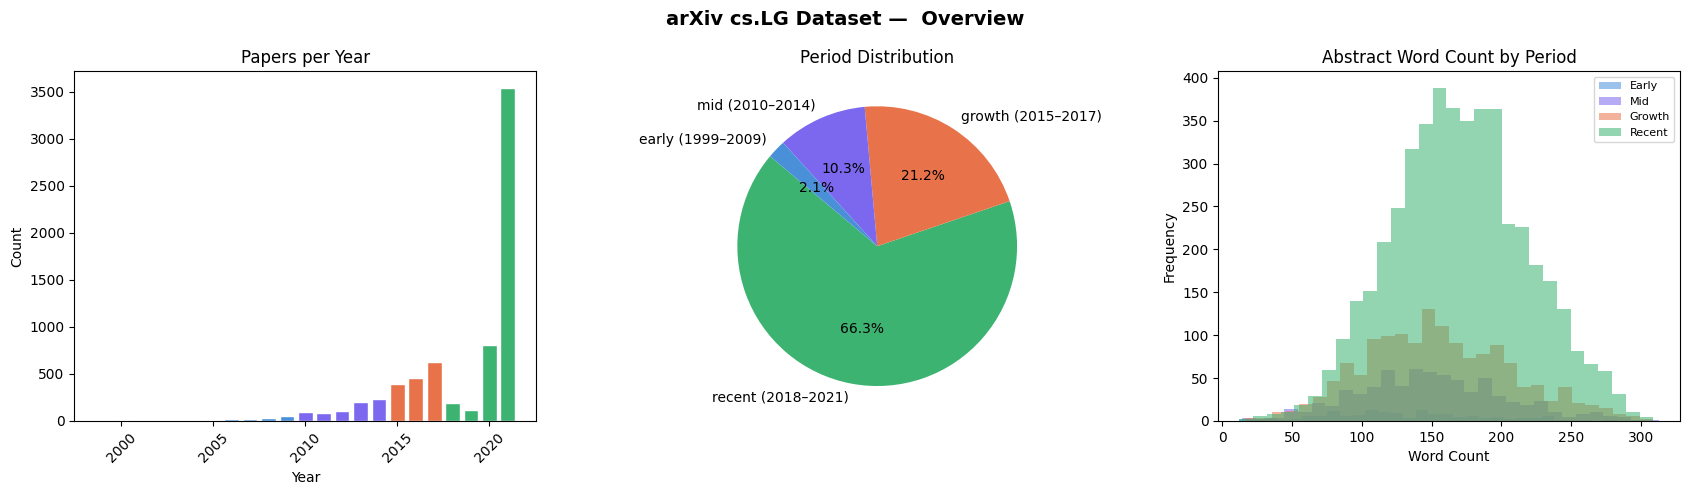

   ✅ Saved Overview.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("arXiv cs.LG Dataset —  Overview", fontsize=14, fontweight='bold')

period_colors = {
    'early (1999–2009)' : '#4A90D9',
    'mid (2010–2014)'   : '#7B68EE',
    'growth (2015–2017)': '#E8734A',
    'recent (2018–2021)': '#3CB371',
}


year_counts = df['year'].value_counts().sort_index()
bar_colors  = [period_colors[assign_period(y)] for y in year_counts.index]
axes[0].bar(year_counts.index, year_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title("Papers per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


period_counts = df['period'].value_counts()
axes[1].pie(
    period_counts.values,
    labels=period_counts.index,
    colors=[period_colors[p] for p in period_counts.index],
    autopct='%1.1f%%', startangle=140
)
axes[1].set_title("Period Distribution")


for period, color in period_colors.items():
    subset = df[df['period'] == period]['word_count']
    if len(subset):
        axes[2].hist(subset, bins=30, alpha=0.55,
                     label=period.split()[0].capitalize(), color=color)
axes[2].set_title("Abstract Word Count by Period")
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Frequency")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../Results/Overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Saved Overview.png")